# 💳 Credit Card Fraud Detection System
### AI & Machine Learning Project

---

**Techniques used:**
- 📊 Exploratory Data Analysis (EDA)
- ⚖️ Class Imbalance Handling: SMOTE, Undersampling, Isolation Forest
- 🤖 Models: Logistic Regression · Random Forest · XGBoost
- 📈 Evaluation: Accuracy · Precision · Recall · F1 · ROC-AUC

---

> **SETUP:**  
> 1. Upload `creditcard.csv` using the cell below  
> 2. Then run all remaining cells (`Runtime → Run all`)

## 📦 Step 1 — Install Dependencies & Upload Dataset

In [1]:
# Install all required libraries
!pip install -q imbalanced-learn xgboost scikit-learn matplotlib seaborn pandas numpy
print('✅ Libraries installed successfully!')

✅ Libraries installed successfully!


In [2]:
# VS Code version — read directly from folder
import pandas as pd
df = pd.read_csv('creditcard.csv')
print(f'✅ Dataset loaded: {df.shape}')

✅ Dataset loaded: (284807, 31)


## 📚 Step 2 — Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    accuracy_score, f1_score, precision_score, recall_score,
    average_precision_score
)
from sklearn.pipeline import Pipeline

# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# XGBoost
from xgboost import XGBClassifier

# Plot settings
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
RANDOM_STATE = 42

print('✅ All libraries imported!')

✅ All libraries imported!


## 📂 Step 3 — Load & Inspect Dataset

In [4]:
# Load the uploaded CSV
import io
print(df.shape)

print('=' * 60)
print('  DATASET OVERVIEW')
print('=' * 60)
print(f'  Shape            : {df.shape[0]:,} rows  x  {df.shape[1]} columns')
print(f'  Memory usage     : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')
print(f'  Missing values   : {df.isnull().sum().sum()}')
print(f'  Duplicate rows   : {df.duplicated().sum()}')
print('=' * 60)

print('\n📊 Class Distribution:')
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100
print(f'  Legitimate  (0)  : {class_counts[0]:,}  ({class_pct[0]:.4f}%)')
print(f'  Fraudulent  (1)  : {class_counts[1]:,}  ({class_pct[1]:.4f}%)')
print(f'  Imbalance Ratio  : {class_counts[0]/class_counts[1]:.0f} : 1')

df.head()

(284807, 31)
  DATASET OVERVIEW
  Shape            : 284,807 rows  x  31 columns
  Memory usage     : 70.63 MB
  Missing values   : 0
  Duplicate rows   : 1081

📊 Class Distribution:
  Legitimate  (0)  : 284,315  (99.8273%)
  Fraudulent  (1)  : 492  (0.1727%)
  Imbalance Ratio  : 578 : 1


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Statistical summary
print('📋 Statistical Summary (Amount & Time):')
df[['Time', 'Amount', 'Class']].describe().round(4)

📋 Statistical Summary (Amount & Time):


,Time,Amount,Class
count,284807.0000,284807.0000,284807.0000
mean,94813.8596,88.3496,0.0017
std,47488.1460,250.1201,0.0415
min,0.0000,0.0000,0.0000
25%,54201.5000,5.6000,0.0000
50%,84692.0000,22.0000,0.0000
75%,139320.5000,77.1650,0.0000
max,172792.0000,25691.1600,1.0000


## 📊 Step 4 — Exploratory Data Analysis (EDA)

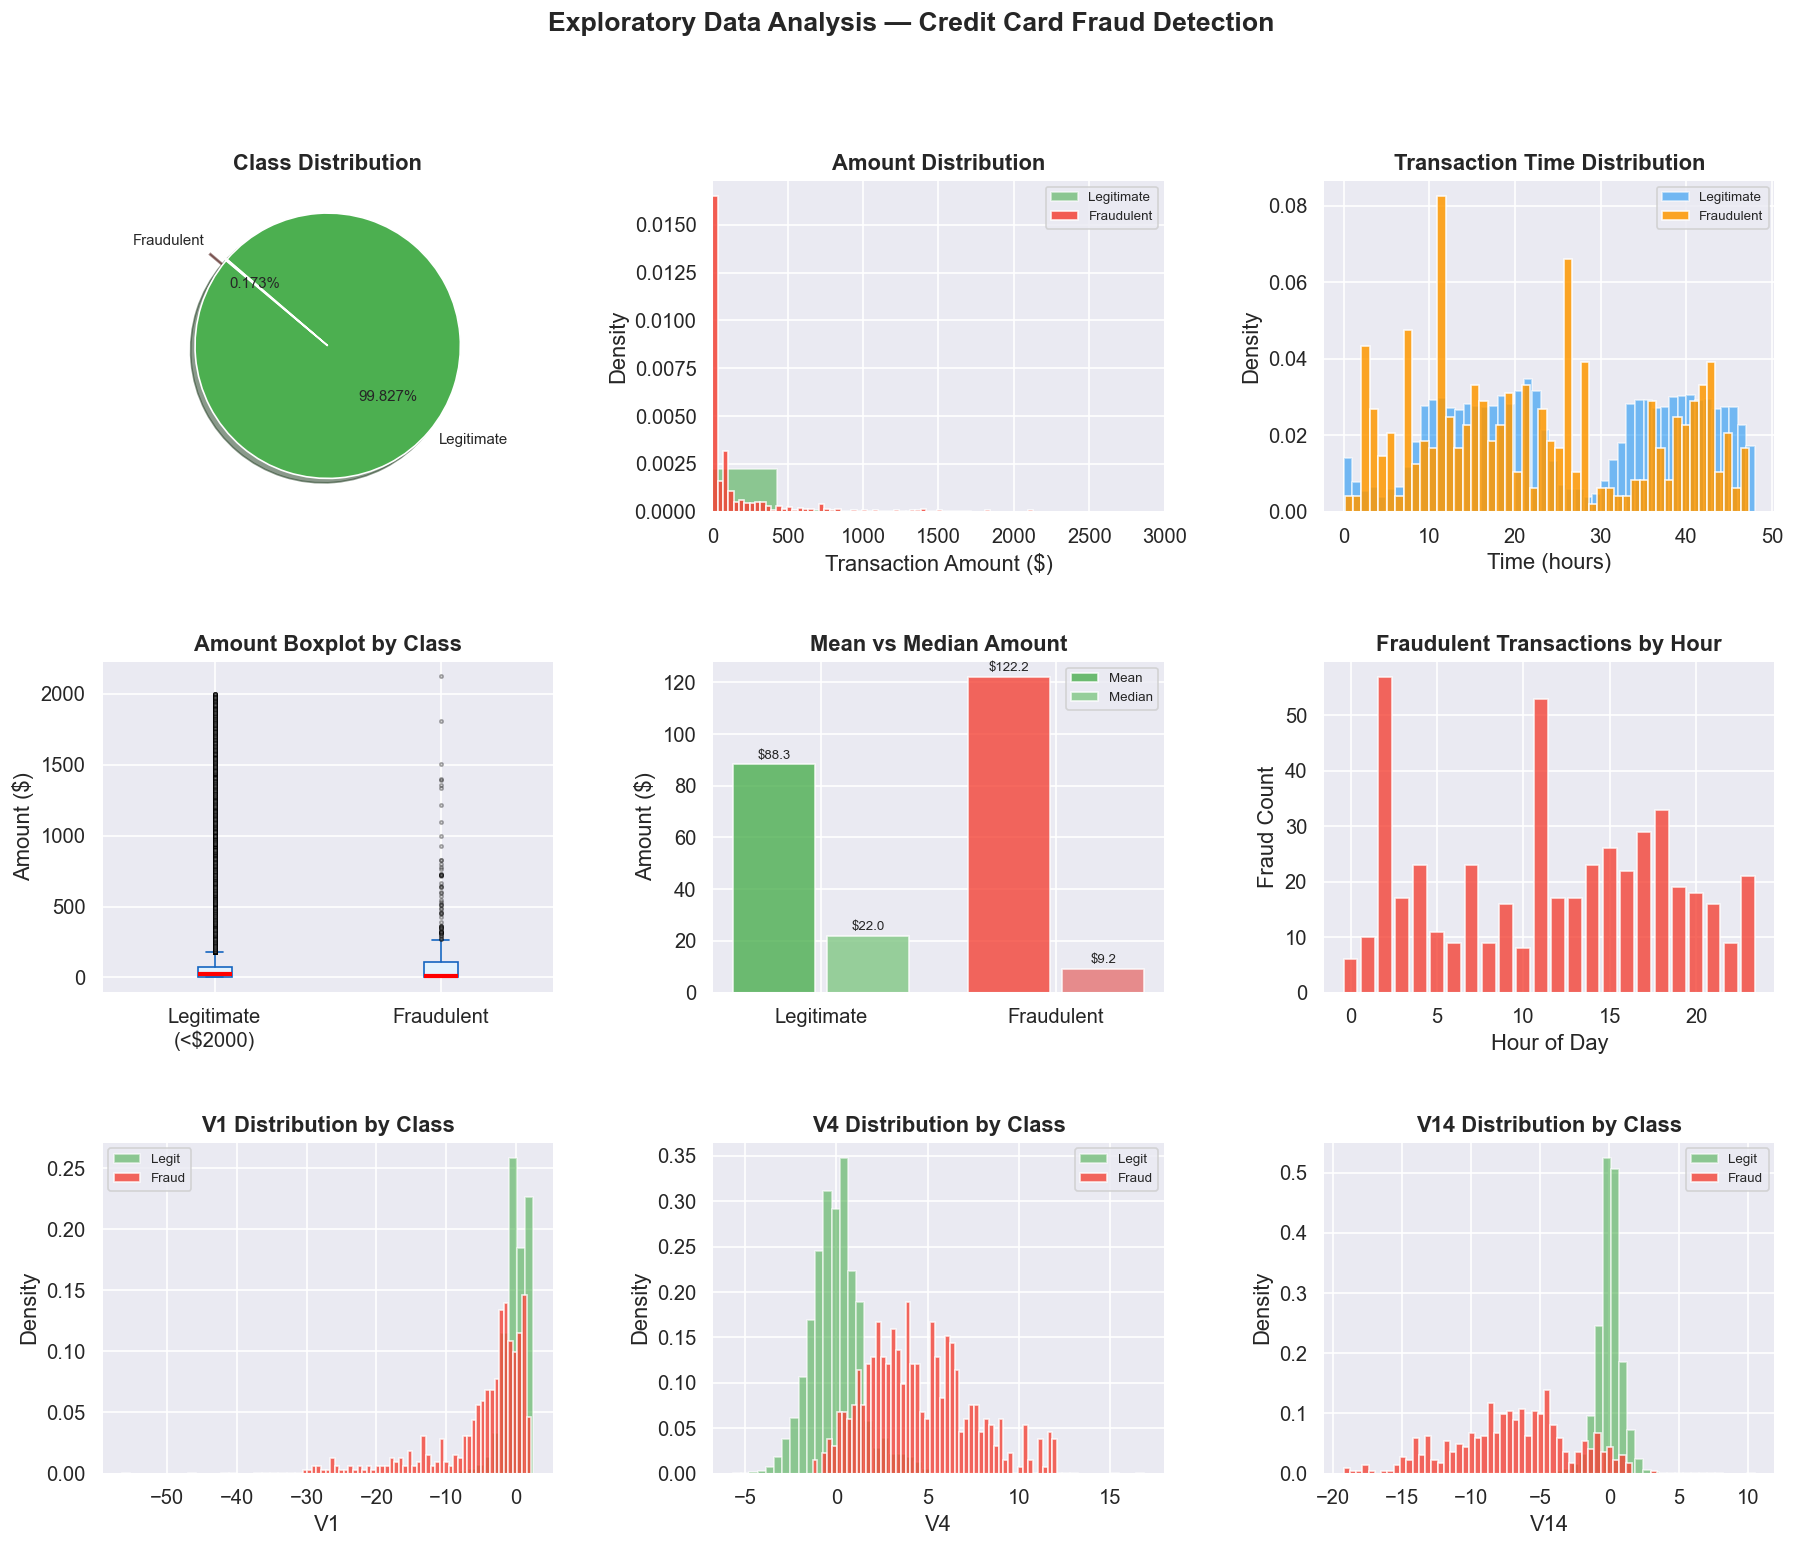

✅ EDA plot saved as eda_overview.png


In [6]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Exploratory Data Analysis — Credit Card Fraud Detection',
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# --- 1. Pie chart ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.pie(
    [class_counts[0], class_counts[1]],
    labels=['Legitimate', 'Fraudulent'],
    colors=['#4CAF50', '#F44336'],
    autopct='%1.3f%%', explode=(0, 0.12),
    shadow=True, startangle=140,
    textprops={'fontsize': 9}
)
ax1.set_title('Class Distribution', fontweight='bold')

# --- 2. Amount histogram ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df[df['Class']==0]['Amount'], bins=60, alpha=0.6,
         color='#4CAF50', label='Legitimate', density=True)
ax2.hist(df[df['Class']==1]['Amount'], bins=60, alpha=0.85,
         color='#F44336', label='Fraudulent', density=True)
ax2.set_xlabel('Transaction Amount ($)')
ax2.set_ylabel('Density')
ax2.set_title('Amount Distribution', fontweight='bold')
ax2.set_xlim(0, 3000)
ax2.legend(fontsize=8)

# --- 3. Time distribution ---
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(df[df['Class']==0]['Time']/3600, bins=48, alpha=0.6,
         color='#2196F3', label='Legitimate', density=True)
ax3.hist(df[df['Class']==1]['Time']/3600, bins=48, alpha=0.85,
         color='#FF9800', label='Fraudulent', density=True)
ax3.set_xlabel('Time (hours)')
ax3.set_ylabel('Density')
ax3.set_title('Transaction Time Distribution', fontweight='bold')
ax3.legend(fontsize=8)

# --- 4. Amount boxplot ---
ax4 = fig.add_subplot(gs[1, 0])
fraud_amt = df[df['Class']==1]['Amount']
legit_amt = df[df['Class']==0]['Amount']
ax4.boxplot(
    [legit_amt[legit_amt < 2000], fraud_amt],
    labels=['Legitimate\n(<$2000)', 'Fraudulent'],
    patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD', color='#1565C0'),
    medianprops=dict(color='red', linewidth=2.5),
    whiskerprops=dict(color='#1565C0'),
    capprops=dict(color='#1565C0'),
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=2, alpha=0.3)
)
ax4.set_ylabel('Amount ($)')
ax4.set_title('Amount Boxplot by Class', fontweight='bold')

# --- 5. Average amounts ---
ax5 = fig.add_subplot(gs[1, 1])
avg_data = pd.DataFrame({
    'Class': ['Legitimate', 'Fraudulent'],
    'Mean Amount': [legit_amt.mean(), fraud_amt.mean()],
    'Median Amount': [legit_amt.median(), fraud_amt.median()]
})
x_idx = np.arange(2)
bars1 = ax5.bar(x_idx - 0.2, avg_data['Mean Amount'],   0.35,
                label='Mean',   color=['#4CAF50','#F44336'], alpha=0.8)
bars2 = ax5.bar(x_idx + 0.2, avg_data['Median Amount'], 0.35,
                label='Median', color=['#81C784','#E57373'], alpha=0.8)
for bar in list(bars1)+list(bars2):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'${bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
ax5.set_xticks(x_idx)
ax5.set_xticklabels(['Legitimate', 'Fraudulent'])
ax5.set_ylabel('Amount ($)')
ax5.set_title('Mean vs Median Amount', fontweight='bold')
ax5.legend(fontsize=8)

# --- 6. Fraud by time of day (hour buckets) ---
ax6 = fig.add_subplot(gs[1, 2])
fraud_df   = df[df['Class']==1].copy()
fraud_df['hour'] = (fraud_df['Time'] / 3600).astype(int) % 24
hourly     = fraud_df.groupby('hour').size()
ax6.bar(hourly.index, hourly.values, color='#F44336', alpha=0.8, edgecolor='white')
ax6.set_xlabel('Hour of Day')
ax6.set_ylabel('Fraud Count')
ax6.set_title('Fraudulent Transactions by Hour', fontweight='bold')

# --- 7–9. Feature distributions (V1, V4, V14 are top fraud indicators) ---
for i, feat in enumerate(['V1', 'V4', 'V14']):
    ax = fig.add_subplot(gs[2, i])
    ax.hist(df[df['Class']==0][feat], bins=50, alpha=0.6,
            color='#4CAF50', label='Legit', density=True)
    ax.hist(df[df['Class']==1][feat], bins=50, alpha=0.8,
            color='#F44336', label='Fraud', density=True)
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.set_title(f'{feat} Distribution by Class', fontweight='bold')
    ax.legend(fontsize=8)

plt.savefig('eda_overview.png', bbox_inches='tight', dpi=130)
plt.show()
print('✅ EDA plot saved as eda_overview.png')

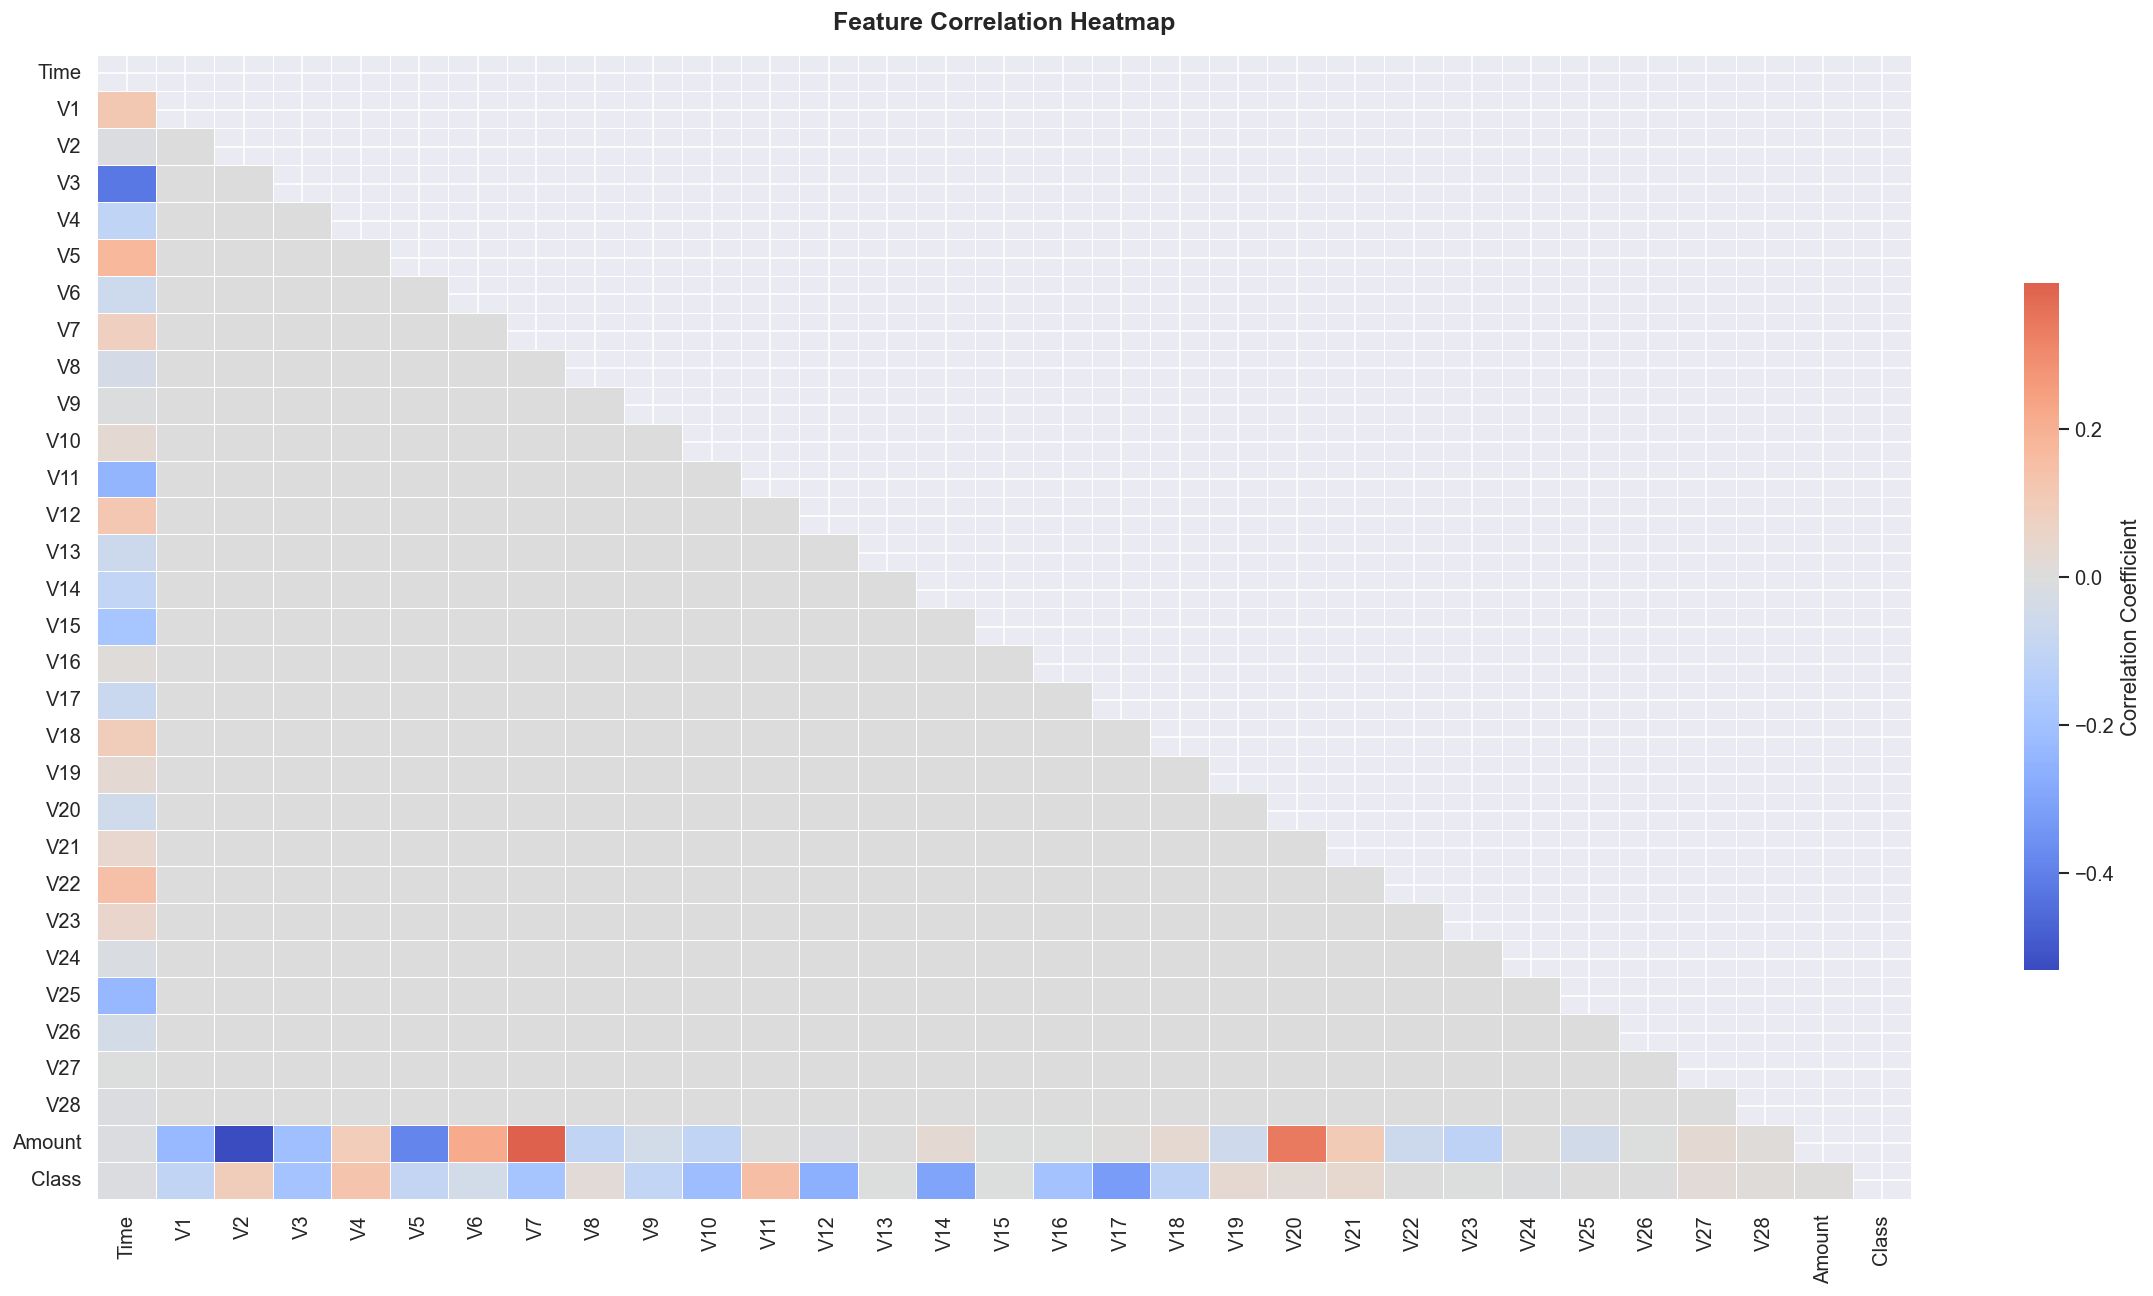


🔍 Top 10 Features Most Correlated with Fraud:
   V17   : 0.3265
   V14   : 0.3025
   V12   : 0.2606
   V10   : 0.2169
   V16   : 0.1965
   V3    : 0.1930
   V7    : 0.1873
   V11   : 0.1549
   V4    : 0.1334
   V18   : 0.1115


In [7]:
# Correlation heatmap
plt.figure(figsize=(20, 11))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm', center=0,
    annot=False, linewidths=0.3,
    cbar_kws={'shrink': 0.6, 'label': 'Correlation Coefficient'}
)
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()

# Top correlated features with Class
class_corr = corr['Class'].drop('Class').abs().sort_values(ascending=False)
print('\n🔍 Top 10 Features Most Correlated with Fraud:')
for feat, val in class_corr.head(10).items():
    print(f'   {feat:<6}: {val:.4f}')

## 🧹 Step 5 — Data Preprocessing & Feature Engineering

In [8]:
print('🧹 Preprocessing steps:')

# 1. Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f'  [1] Removed {before - len(df):,} duplicate rows. Remaining: {len(df):,}')

# 2. Scale Amount and Time using StandardScaler
#    (V1-V28 are already PCA-transformed & scaled)
scaler_amount = StandardScaler()
scaler_time   = StandardScaler()

df['scaled_Amount'] = scaler_amount.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_Time']   = scaler_time.fit_transform(df['Time'].values.reshape(-1, 1))
df.drop(['Amount', 'Time'], axis=1, inplace=True)
print('  [2] Scaled Amount and Time features.')

# 3. Split features and target
X = df.drop('Class', axis=1)
y = df['Class']
print(f'  [3] Feature matrix : {X.shape}')
print(f'      Target vector  : {y.shape}')
print(f'      Features       : {list(X.columns)}')

print('\n✅ Preprocessing complete!')

🧹 Preprocessing steps:
  [1] Removed 1,081 duplicate rows. Remaining: 283,726
  [2] Scaled Amount and Time features.
  [3] Feature matrix : (283726, 30)
      Target vector  : (283726,)
      Features       : ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'scaled_Amount', 'scaled_Time']

✅ Preprocessing complete!


In [9]:
# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('📂 Train / Test Split (80% / 20%)')
print(f'  Training set : {X_train.shape[0]:,} samples')
print(f'  Test set     : {X_test.shape[0]:,} samples')
print(f'\n  Train class distribution:')
tc = y_train.value_counts()
print(f'    Legitimate : {tc[0]:,}')
print(f'    Fraudulent : {tc[1]:,}')

📂 Train / Test Split (80% / 20%)
  Training set : 226,980 samples
  Test set     : 56,746 samples

  Train class distribution:
    Legitimate : 226,602
    Fraudulent : 378


## ⚖️ Step 6 — Class Imbalance Handling

In [10]:
# ── SMOTE: Synthetic Minority Oversampling ──────────────────────
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('✅ SMOTE Oversampling:')
vc = pd.Series(y_train_smote).value_counts()
print(f'   Legitimate : {vc[0]:,}')
print(f'   Fraudulent : {vc[1]:,}')
print(f'   Total      : {X_train_smote.shape[0]:,}')

# ── Random Undersampling ────────────────────────────────────────
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print('\n✅ Random Undersampling:')
vc2 = pd.Series(y_train_under).value_counts()
print(f'   Legitimate : {vc2[0]:,}')
print(f'   Fraudulent : {vc2[1]:,}')
print(f'   Total      : {X_train_under.shape[0]:,}')

# ── SMOTETomek (combined) ───────────────────────────────────────
smt = SMOTETomek(random_state=RANDOM_STATE)
X_train_smt, y_train_smt = smt.fit_resample(X_train, y_train)

print('\n✅ SMOTETomek (Hybrid):')
vc3 = pd.Series(y_train_smt).value_counts()
print(f'   Legitimate : {vc3[0]:,}')
print(f'   Fraudulent : {vc3[1]:,}')
print(f'   Total      : {X_train_smt.shape[0]:,}')

✅ SMOTE Oversampling:
   Legitimate : 226,602
   Fraudulent : 226,602
   Total      : 453,204

✅ Random Undersampling:
   Legitimate : 378
   Fraudulent : 378
   Total      : 756

✅ SMOTETomek (Hybrid):
   Legitimate : 226,602
   Fraudulent : 226,602
   Total      : 453,204


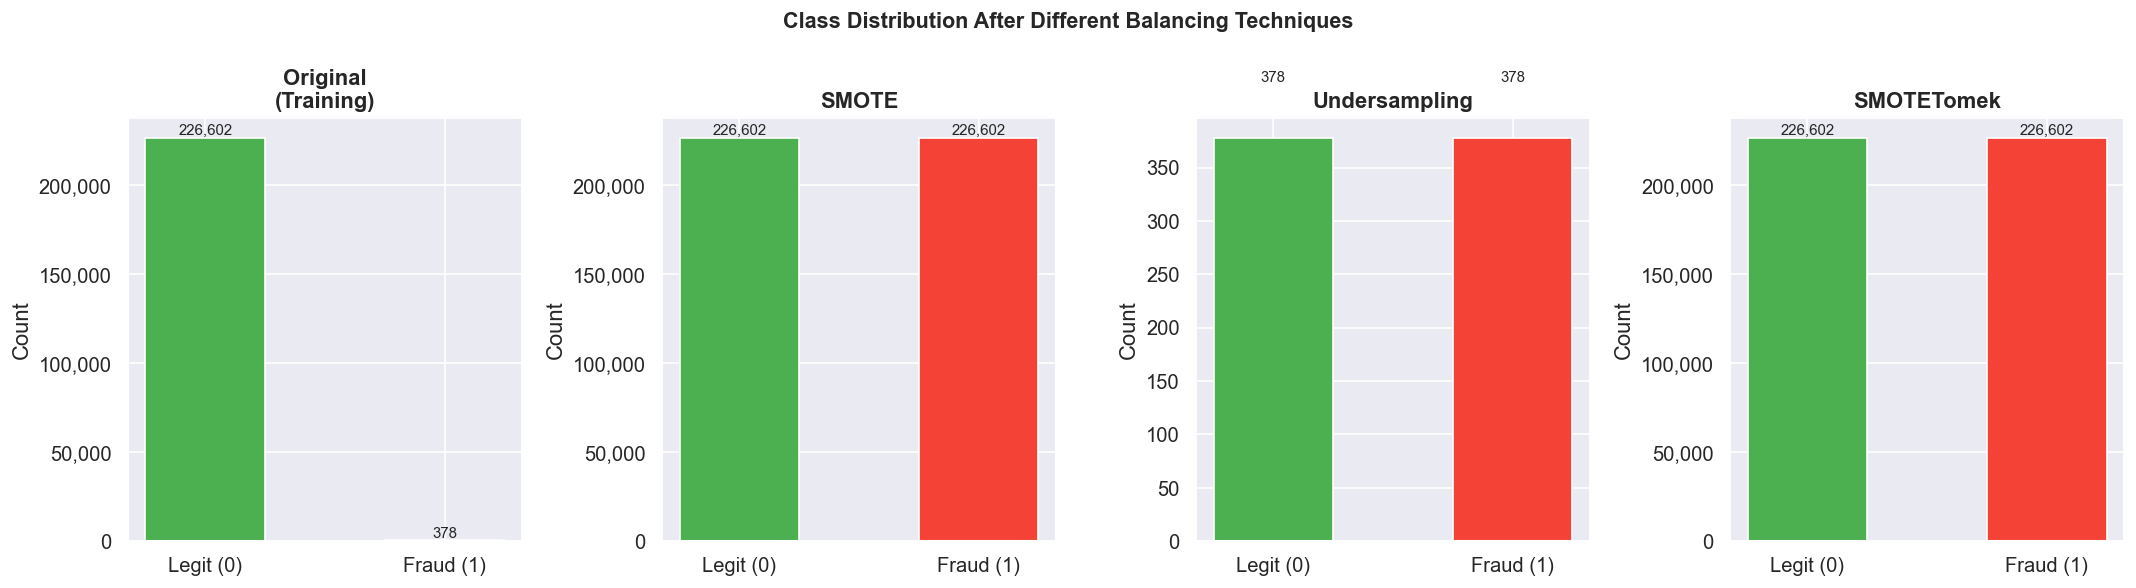

In [11]:
# Visualize class balancing
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Class Distribution After Different Balancing Techniques',
             fontsize=13, fontweight='bold')

datasets = [
    ('Original\n(Training)', y_train),
    ('SMOTE', pd.Series(y_train_smote)),
    ('Undersampling', pd.Series(y_train_under)),
    ('SMOTETomek', pd.Series(y_train_smt)),
]
colors = [['#4CAF50','#F44336']] * 4

for ax, (title, y_data), clr in zip(axes, datasets, colors):
    vc = y_data.value_counts()
    bars = ax.bar(['Legit (0)', 'Fraud (1)'],
                  [vc.get(0,0), vc.get(1,0)],
                  color=clr, edgecolor='white', width=0.5)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('class_balancing.png', bbox_inches='tight', dpi=120)
plt.show()

## 🌲 Step 7 — Anomaly Detection: Isolation Forest

In [12]:
print('🌲 Training Isolation Forest...')

iso_model = IsolationForest(
    n_estimators=200,
    contamination=float(y_train.sum()) / len(y_train),  # actual fraud rate
    max_features=1.0,
    bootstrap=False,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_model.fit(X_train)

# Predict (-1=anomaly → 1=fraud, 1=normal → 0=legit)
y_pred_iso_raw = iso_model.predict(X_test)
y_pred_iso     = np.where(y_pred_iso_raw == -1, 1, 0)

# Anomaly scores (lower = more anomalous)
iso_scores     = -iso_model.decision_function(X_test)

print('\n📊 Isolation Forest — Classification Report:')
print(classification_report(y_test, y_pred_iso,
                             target_names=['Legitimate','Fraudulent']))
print(f'ROC-AUC Score : {roc_auc_score(y_test, iso_scores):.4f}')

🌲 Training Isolation Forest...

📊 Isolation Forest — Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
  Fraudulent       0.24      0.24      0.24        95

    accuracy                           1.00     56746
   macro avg       0.62      0.62      0.62     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC Score : 0.9377


## 🤖 Step 8 — Supervised ML Models

In [13]:
# ── Logistic Regression ─────────────────────────────────────────
print('📈 Training Logistic Regression...')

lr_model = LogisticRegression(
    max_iter=2000,
    solver='saga',
    C=0.1,
    penalty='l2',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lr_model.fit(X_train_smote, y_train_smote)

y_pred_lr  = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]

print('\n📊 Logistic Regression — Classification Report:')
print(classification_report(y_test, y_pred_lr,
                             target_names=['Legitimate','Fraudulent']))
print(f'ROC-AUC Score : {roc_auc_score(y_test, y_proba_lr):.4f}')

📈 Training Logistic Regression...

📊 Logistic Regression — Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56651
  Fraudulent       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

ROC-AUC Score : 0.9619


In [ ]:
    # ── Random Forest ───────────────────────────────────────────────
print('🌳 Training Random Forest...')

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf  = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print('\n📊 Random Forest — Classification Report:')
print(classification_report(y_test, y_pred_rf,
                             target_names=['Legitimate','Fraudulent']))
print(f'ROC-AUC Score : {roc_auc_score(y_test, y_proba_rf):.4f}')

🌳 Training Random Forest...

📊 Random Forest — Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
  Fraudulent       0.83      0.77      0.80        95

    accuracy                           1.00     56746
   macro avg       0.91      0.88      0.90     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC Score : 0.9704


In [15]:
# ── XGBoost ─────────────────────────────────────────────────────
print('⚡ Training XGBoost...')

neg = (y_train_smote == 0).sum()
pos = (y_train_smote == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg/pos,
    eval_metric='aucpr',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_xgb  = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print('\n📊 XGBoost — Classification Report:')
print(classification_report(y_test, y_pred_xgb,
                             target_names=['Legitimate','Fraudulent']))
print(f'ROC-AUC Score : {roc_auc_score(y_test, y_proba_xgb):.4f}')

⚡ Training XGBoost...

📊 XGBoost — Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
  Fraudulent       0.58      0.80      0.67        95

    accuracy                           1.00     56746
   macro avg       0.79      0.90      0.83     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC Score : 0.9747


## 📈 Step 9 — Model Evaluation & Comparison

In [16]:
def compute_metrics(y_true, y_pred, y_proba=None):
    return {
        'Accuracy'  : round(accuracy_score(y_true, y_pred), 4),
        'Precision' : round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_true, y_pred), 4),
        'F1-Score'  : round(f1_score(y_true, y_pred), 4),
        'ROC-AUC'   : round(roc_auc_score(y_true, y_proba if y_proba is not None else y_pred), 4),
        'Avg Prec'  : round(average_precision_score(y_true, y_proba if y_proba is not None else y_pred), 4),
    }

results = {
    'Isolation Forest'   : compute_metrics(y_test, y_pred_iso, iso_scores),
    'Logistic Regression': compute_metrics(y_test, y_pred_lr,  y_proba_lr),
    'Random Forest'      : compute_metrics(y_test, y_pred_rf,  y_proba_rf),
    'XGBoost'            : compute_metrics(y_test, y_pred_xgb, y_proba_xgb),
}

results_df = pd.DataFrame(results).T

print('=' * 72)
print('  MODEL COMPARISON SUMMARY')
print('=' * 72)
print(results_df.to_string())
print('=' * 72)
print(f'\n🏆 Best ROC-AUC   : {results_df["ROC-AUC"].idxmax()}  ({results_df["ROC-AUC"].max():.4f})')
print(f'🏆 Best F1-Score  : {results_df["F1-Score"].idxmax()}  ({results_df["F1-Score"].max():.4f})')
print(f'🏆 Best Recall    : {results_df["Recall"].idxmax()}  ({results_df["Recall"].max():.4f})')

  MODEL COMPARISON SUMMARY
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  Avg Prec
Isolation Forest       0.9974     0.2371  0.2421    0.2396   0.9377    0.1290
Logistic Regression    0.9739     0.0534  0.8737    0.1007   0.9619    0.6738
Random Forest          0.9993     0.8295  0.7684    0.7978   0.9704    0.8050
XGBoost                0.9987     0.5758  0.8000    0.6696   0.9747    0.7981

🏆 Best ROC-AUC   : XGBoost  (0.9747)
🏆 Best F1-Score  : Random Forest  (0.7978)
🏆 Best Recall    : Logistic Regression  (0.8737)


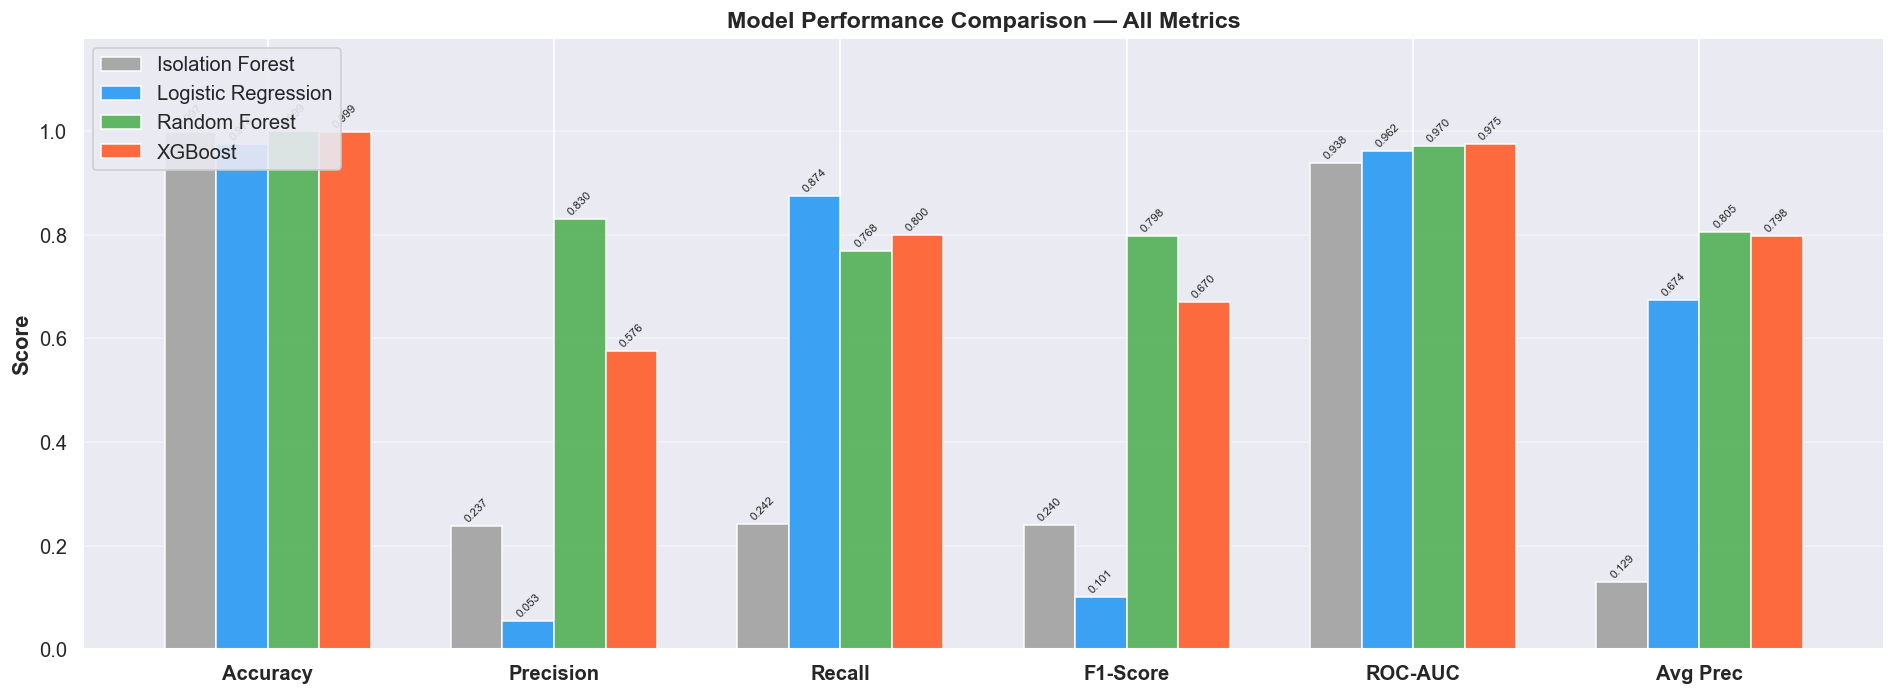

In [17]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(16, 6))

metrics = list(results_df.columns)
models  = list(results_df.index)
x       = np.arange(len(metrics))
width   = 0.18
palette = ['#9E9E9E', '#2196F3', '#4CAF50', '#FF5722']

for i, (model, color) in enumerate(zip(models, palette)):
    vals = results_df.loc[model].values
    bars = ax.bar(x + i*width, vals, width,
                  label=model, color=color, alpha=0.87, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontweight='bold')
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Model Performance Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(axis='y', alpha=0.35)

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

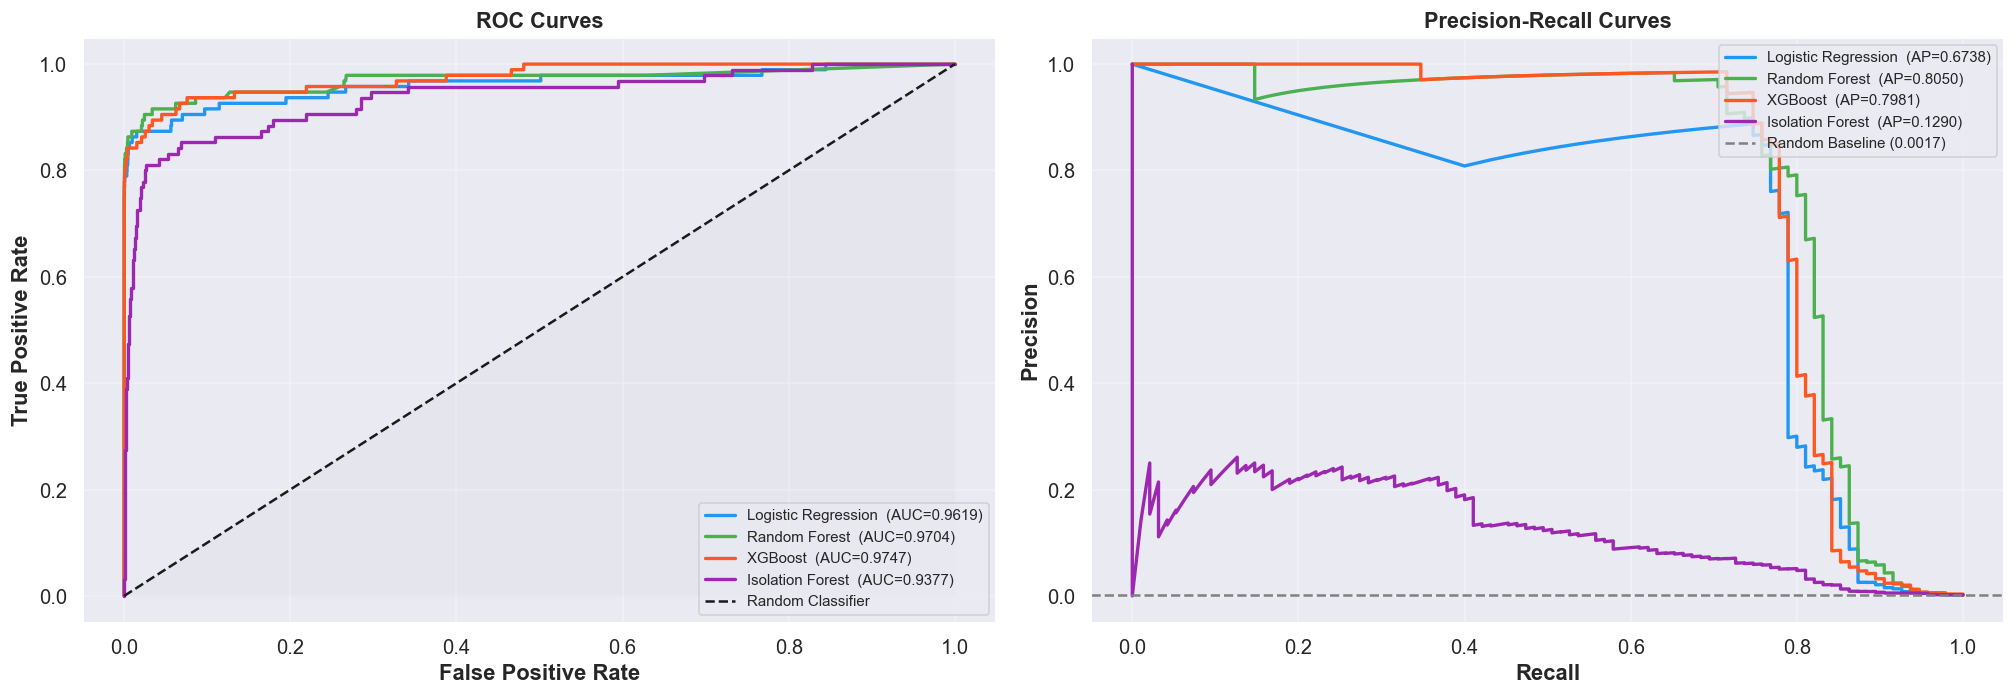

In [18]:
# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

model_data = [
    ('Logistic Regression', y_proba_lr,  '#2196F3'),
    ('Random Forest',       y_proba_rf,  '#4CAF50'),
    ('XGBoost',             y_proba_xgb, '#FF5722'),
    ('Isolation Forest',    iso_scores,  '#9C27B0'),
]

# --- ROC curve ---
ax = axes[0]
for name, proba, color in model_data:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name}  (AUC={auc:.4f})', color=color, lw=2)
ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Random Classifier')
ax.fill_between([0,1],[0,1], alpha=0.04, color='gray')
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('ROC Curves', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

# --- Precision-Recall curve ---
ax2 = axes[1]
for name, proba, color in model_data:
    p, r, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax2.plot(r, p, label=f'{name}  (AP={ap:.4f})', color=color, lw=2)
baseline = y_test.sum() / len(y_test)
ax2.axhline(baseline, linestyle='--', color='gray', lw=1.5,
            label=f'Random Baseline ({baseline:.4f})')
ax2.set_xlabel('Recall', fontweight='bold')
ax2.set_ylabel('Precision', fontweight='bold')
ax2.set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', bbox_inches='tight', dpi=120)
plt.show()

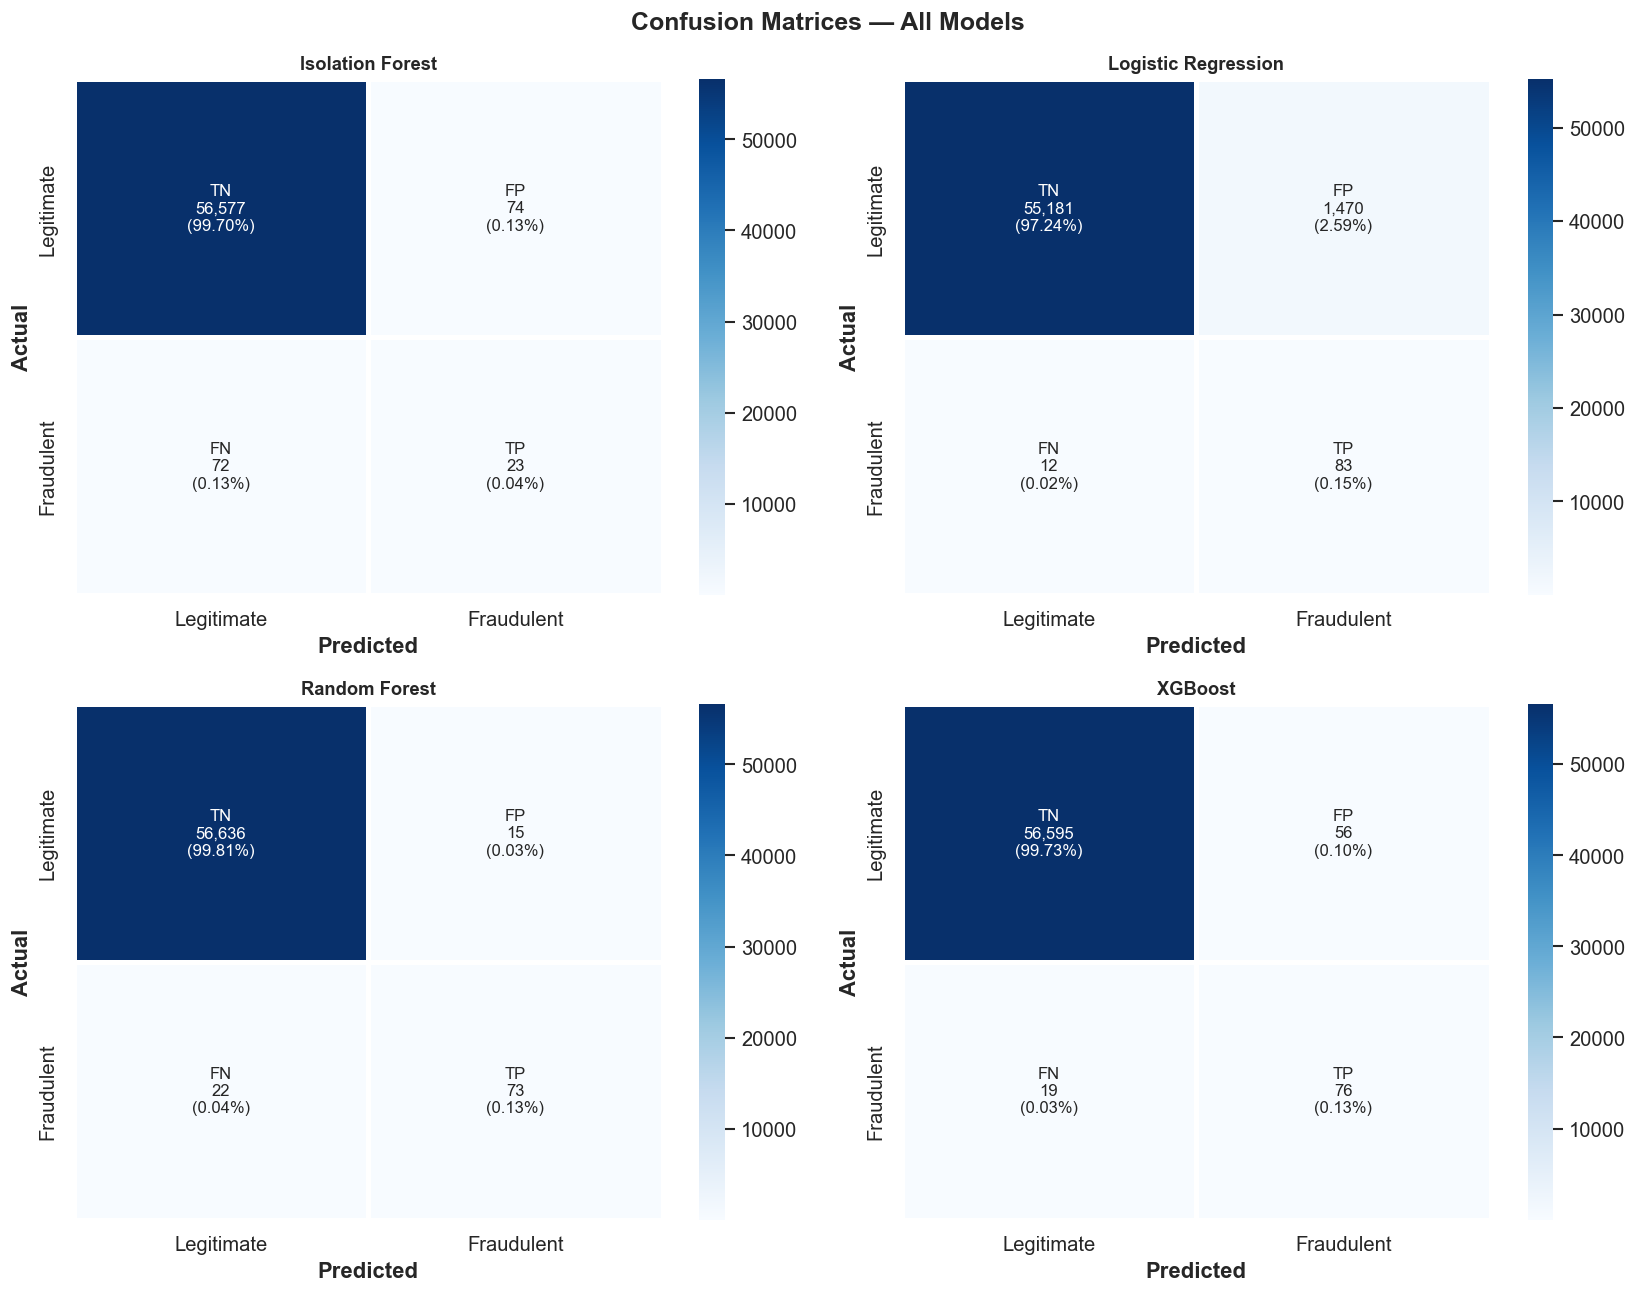

In [19]:
# Confusion matrices — 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')

preds = [
    ('Isolation Forest',    y_pred_iso),
    ('Logistic Regression', y_pred_lr),
    ('Random Forest',       y_pred_rf),
    ('XGBoost',             y_pred_xgb),
]

for ax, (name, pred) in zip(axes.flat, preds):
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Annotate with both count and percentage
    total = cm.sum()
    labels = np.array([
        [f'TN\n{tn:,}\n({tn/total*100:.2f}%)', f'FP\n{fp:,}\n({fp/total*100:.2f}%)'],
        [f'FN\n{fn:,}\n({fn/total*100:.2f}%)', f'TP\n{tp:,}\n({tp/total*100:.2f}%)']
    ])
    
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax,
                xticklabels=['Legitimate','Fraudulent'],
                yticklabels=['Legitimate','Fraudulent'],
                linewidths=2, linecolor='white',
                annot_kws={'size': 10})
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted', fontweight='bold')
    ax.set_ylabel('Actual', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=120)
plt.show()

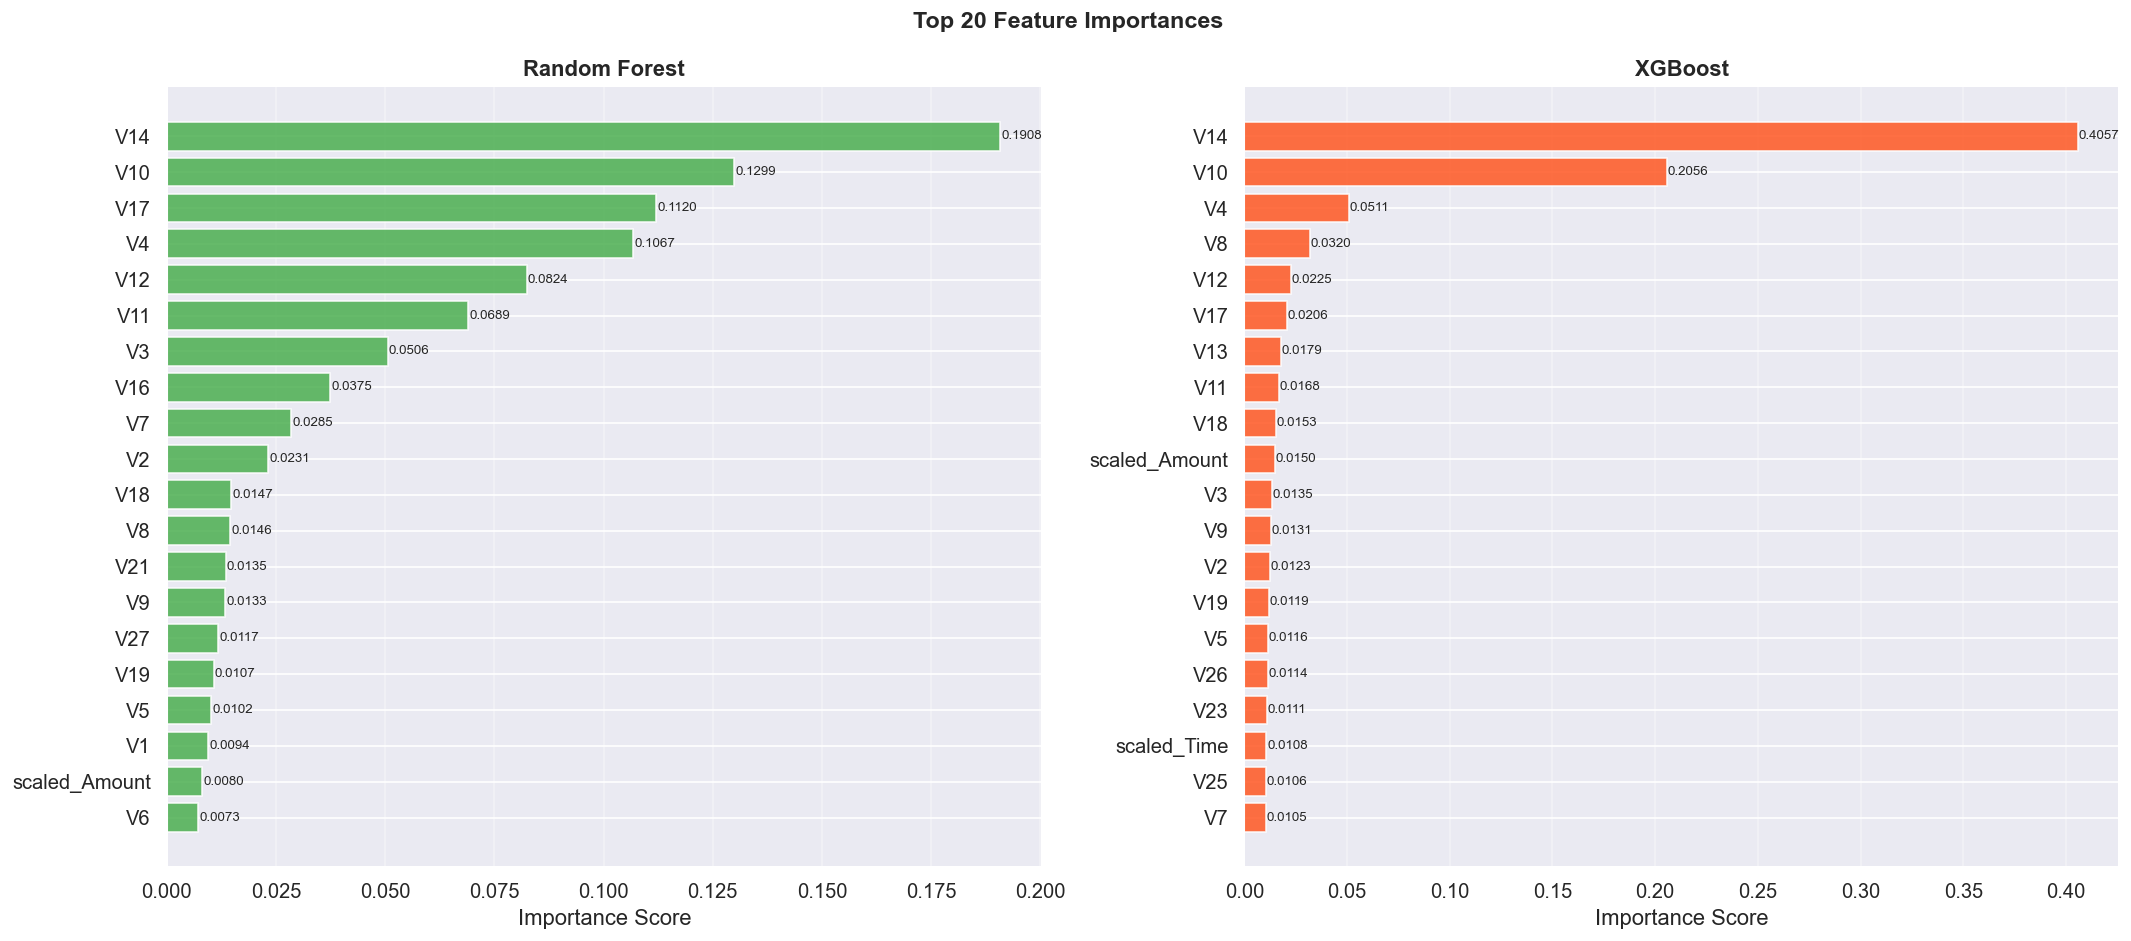

In [20]:
# Feature Importance — Random Forest & XGBoost
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Top 20 Feature Importances', fontsize=14, fontweight='bold')

for ax, (model, name, color) in zip(axes, [
    (rf_model,  'Random Forest', '#4CAF50'),
    (xgb_model, 'XGBoost',       '#FF5722'),
]):
    imp = pd.Series(model.feature_importances_, index=X.columns)
    top = imp.nlargest(20).sort_values()
    bars = ax.barh(top.index, top.values,
                   color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.0003, bar.get_y()+bar.get_height()/2,
                f'{w:.4f}', va='center', fontsize=8)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.35)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()

## 🔄 Step 10 — Cross-Validation

🔄 5-Fold Stratified Cross-Validation (ROC-AUC)...
   (Running on full dataset — may take a few minutes)

  Logistic Regression
    Folds   : [np.float64(0.9778), np.float64(0.9806), np.float64(0.9831), np.float64(0.9683), np.float64(0.9811)]
    Mean    : 0.9782  (±0.0104)

  Random Forest
    Folds   : [np.float64(0.9825), np.float64(0.9665), np.float64(0.9443), np.float64(0.9462), np.float64(0.9637)]
    Mean    : 0.9606  (±0.0282)

  XGBoost
    Folds   : [np.float64(0.9954), np.float64(0.9639), np.float64(0.9719), np.float64(0.9777), np.float64(0.9823)]
    Mean    : 0.9782  (±0.0211)



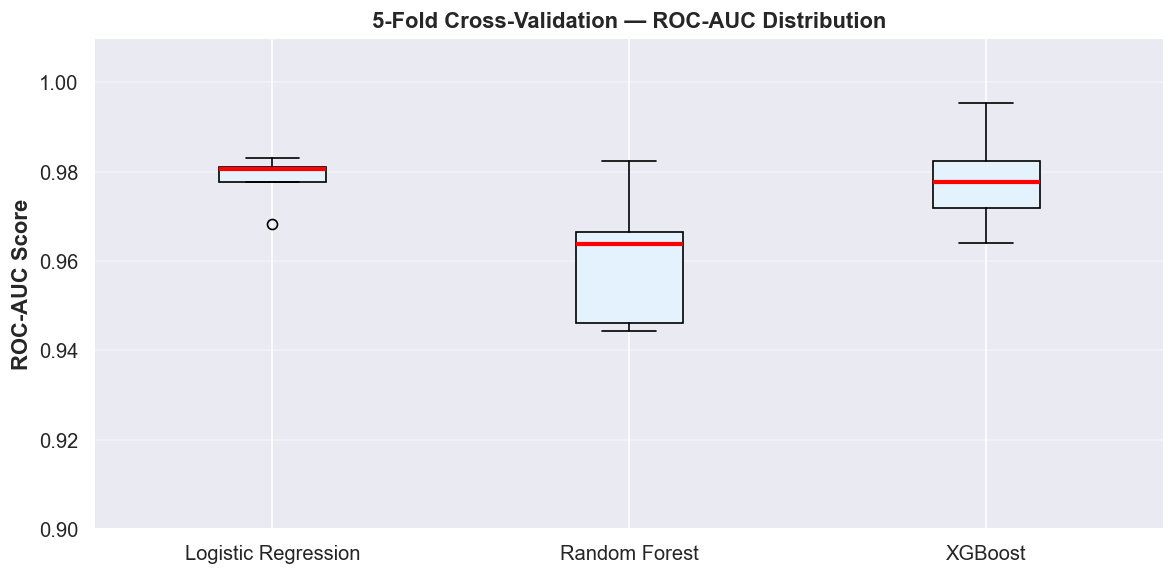

In [21]:
print('🔄 5-Fold Stratified Cross-Validation (ROC-AUC)...')
print('   (Running on full dataset — may take a few minutes)\n')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_models = [
    ('Logistic Regression', LogisticRegression(max_iter=2000, solver='saga',
                                                class_weight='balanced', C=0.1,
                                                random_state=RANDOM_STATE, n_jobs=-1)),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, max_depth=15,
                                                   class_weight='balanced',
                                                   random_state=RANDOM_STATE, n_jobs=-1)),
    ('XGBoost',             XGBClassifier(n_estimators=100, max_depth=5,
                                          learning_rate=0.1, eval_metric='aucpr',
                                          use_label_encoder=False,
                                          random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)),
]

cv_results = {}
for name, model in cv_models:
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'  {name}')
    print(f'    Folds   : {[round(s,4) for s in scores]}')
    print(f'    Mean    : {scores.mean():.4f}  (±{scores.std()*2:.4f})\n')

# Box plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(cv_results.values(), labels=cv_results.keys(),
           patch_artist=True,
           boxprops=dict(facecolor='#E3F2FD'),
           medianprops=dict(color='red', linewidth=2.5))
ax.set_ylabel('ROC-AUC Score', fontweight='bold')
ax.set_title('5-Fold Cross-Validation — ROC-AUC Distribution', fontweight='bold')
ax.set_ylim(0.9, 1.01)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('cross_validation.png', bbox_inches='tight', dpi=120)
plt.show()

## 🎯 Step 11 — Threshold Tuning (XGBoost)

🎯 Optimal Threshold : 0.94
   Best F1-Score     : 0.8284
   Precision         : 0.9459
   Recall            : 0.7368


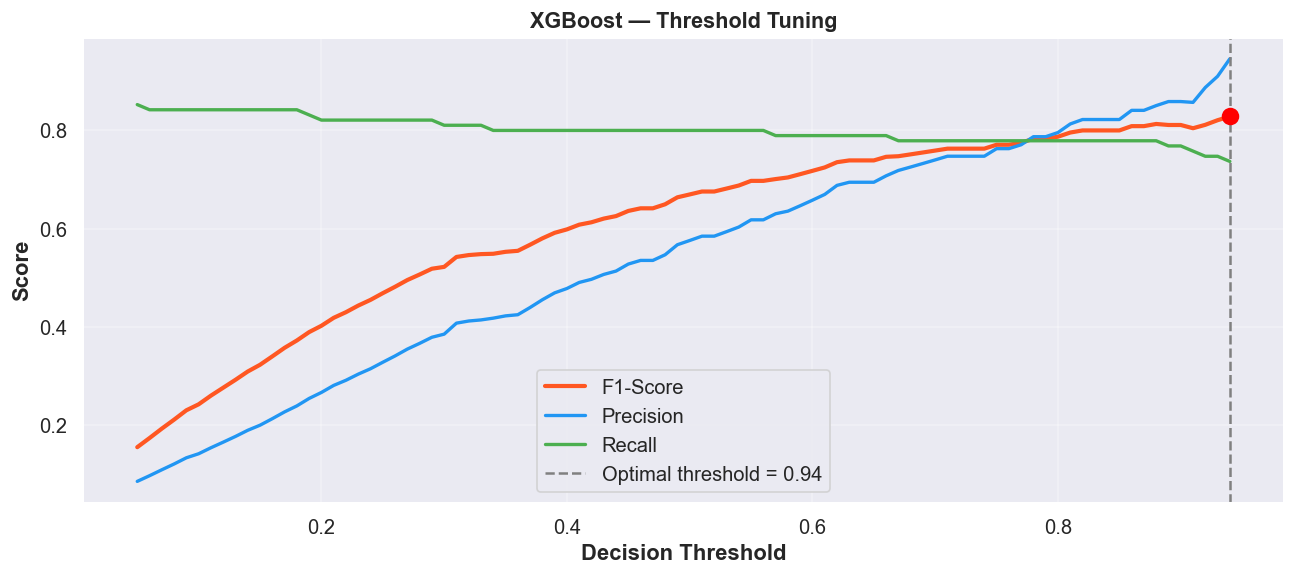

In [22]:
thresholds = np.arange(0.05, 0.95, 0.01)
f1_list, precision_list, recall_list = [], [], []

for t in thresholds:
    y_t = (y_proba_xgb >= t).astype(int)
    f1_list.append(f1_score(y_test, y_t))
    precision_list.append(precision_score(y_test, y_t, zero_division=0))
    recall_list.append(recall_score(y_test, y_t))

best_idx = np.argmax(f1_list)
BEST_THRESHOLD = thresholds[best_idx]

print(f'🎯 Optimal Threshold : {BEST_THRESHOLD:.2f}')
print(f'   Best F1-Score     : {f1_list[best_idx]:.4f}')
print(f'   Precision         : {precision_list[best_idx]:.4f}')
print(f'   Recall            : {recall_list[best_idx]:.4f}')

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds, f1_list,        label='F1-Score',  color='#FF5722', lw=2.5)
ax.plot(thresholds, precision_list, label='Precision', color='#2196F3', lw=2)
ax.plot(thresholds, recall_list,    label='Recall',    color='#4CAF50', lw=2)
ax.axvline(BEST_THRESHOLD, color='gray', ls='--', lw=1.5,
           label=f'Optimal threshold = {BEST_THRESHOLD:.2f}')
ax.scatter([BEST_THRESHOLD], [f1_list[best_idx]],
           color='red', s=90, zorder=5)
ax.set_xlabel('Decision Threshold', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('XGBoost — Threshold Tuning', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_tuning.png', bbox_inches='tight', dpi=120)
plt.show()

## ✅ Step 12 — Final Model Evaluation at Optimal Threshold

In [23]:
y_final = (y_proba_xgb >= BEST_THRESHOLD).astype(int)
cm = confusion_matrix(y_test, y_final)
tn, fp, fn, tp = cm.ravel()

print('=' * 65)
print(f'  FINAL XGBOOST RESULTS  (threshold = {BEST_THRESHOLD:.2f})')
print('=' * 65)
print(classification_report(y_test, y_final,
                             target_names=['Legitimate','Fraudulent']))
print('-' * 65)
print(f'  ROC-AUC Score         : {roc_auc_score(y_test, y_proba_xgb):.4f}')
print(f'  Average Precision     : {average_precision_score(y_test, y_proba_xgb):.4f}')
print('=' * 65)
print(f'\n  Confusion Matrix Breakdown:')
print(f'  ✅ True  Positives  (Fraud caught)       : {tp:,}')
print(f'  ❌ False Positives  (False alarms)        : {fp:,}')
print(f'  ⚠️  False Negatives  (Missed frauds)      : {fn:,}')
print(f'  ✅ True  Negatives  (Correct legitimate)  : {tn:,}')
print(f'\n  Fraud Detection Rate   : {tp/(tp+fn)*100:.2f}%')
print(f'  False Alarm Rate       : {fp/(fp+tn)*100:.4f}%')

  FINAL XGBOOST RESULTS  (threshold = 0.94)
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
  Fraudulent       0.95      0.74      0.83        95

    accuracy                           1.00     56746
   macro avg       0.97      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746

-----------------------------------------------------------------
  ROC-AUC Score         : 0.9747
  Average Precision     : 0.7981

  Confusion Matrix Breakdown:
  ✅ True  Positives  (Fraud caught)       : 70
  ❌ False Positives  (False alarms)        : 4
  ⚠️  False Negatives  (Missed frauds)      : 25
  ✅ True  Negatives  (Correct legitimate)  : 56,647

  Fraud Detection Rate   : 73.68%
  False Alarm Rate       : 0.0071%


## 💾 Step 13 — Save Model

In [24]:
import joblib

joblib.dump(xgb_model,      'xgboost_fraud_model.pkl')
joblib.dump(rf_model,       'random_forest_fraud_model.pkl')
joblib.dump(scaler_amount,  'scaler_amount.pkl')
joblib.dump(scaler_time,    'scaler_time.pkl')

print('✅ Models and scalers saved!')

import glob, os
saved = sorted(glob.glob('*.pkl') + glob.glob('*.png'))
print(f'\n📁 Output files ({len(saved)}):')
for f in saved:
    print(f'   {f:<45} ({os.path.getsize(f)/1024:.1f} KB)')

✅ Models and scalers saved!

📁 Output files (13):
   class_balancing.png                           (47.0 KB)
   confusion_matrices.png                        (107.9 KB)
   correlation_heatmap.png                       (79.1 KB)
   cross_validation.png                          (31.2 KB)
   eda_overview.png                              (205.9 KB)
   feature_importance.png                        (97.4 KB)
   model_comparison.png                          (60.0 KB)
   random_forest_fraud_model.pkl                 (25604.6 KB)
   roc_pr_curves.png                             (121.8 KB)
   scaler_amount.pkl                             (0.6 KB)
   scaler_time.pkl                               (0.6 KB)
   threshold_tuning.png                          (56.6 KB)
   xgboost_fraud_model.pkl                       (951.5 KB)


## 🔮 Step 14 — Live Fraud Prediction Demo

In [25]:
print('🔮 Predicting on 10 random test transactions...\n')
print(f'{"#":<4} {"Actual":<14} {"Predicted":<14} {"Fraud Prob":<14} {"Confidence":<14} {"Verdict"}')
print('-' * 75)

np.random.seed(99)
indices = np.random.choice(len(X_test), size=10, replace=False)

correct = 0
for i, idx in enumerate(indices):
    row    = X_test.iloc[idx]
    actual = y_test.iloc[idx]
    proba  = xgb_model.predict_proba([row])[0][1]
    pred   = int(proba >= BEST_THRESHOLD)
    
    actual_lbl = '🔴 FRAUD'    if actual == 1 else '🟢 Legit'
    pred_lbl   = '🔴 FRAUD'    if pred   == 1 else '🟢 Legit'
    conf       = f'{max(proba, 1-proba)*100:.1f}%'
    verdict    = '✅ Correct'  if pred == actual else '❌ Wrong'
    correct   += (pred == actual)
    
    print(f'{i+1:<4} {actual_lbl:<14} {pred_lbl:<14} {proba:<14.6f} {conf:<14} {verdict}')

print('-' * 75)
print(f'  Accuracy on this sample: {correct}/10 = {correct*10}%')

🔮 Predicting on 10 random test transactions...

#    Actual         Predicted      Fraud Prob     Confidence     Verdict
---------------------------------------------------------------------------
1    🟢 Legit        🟢 Legit        0.000051       100.0%         ✅ Correct
2    🟢 Legit        🟢 Legit        0.000007       100.0%         ✅ Correct
3    🟢 Legit        🟢 Legit        0.007563       99.2%          ✅ Correct
4    🟢 Legit        🟢 Legit        0.000466       100.0%         ✅ Correct
5    🟢 Legit        🟢 Legit        0.000140       100.0%         ✅ Correct
6    🟢 Legit        🟢 Legit        0.000066       100.0%         ✅ Correct
7    🟢 Legit        🟢 Legit        0.000082       100.0%         ✅ Correct
8    🟢 Legit        🟢 Legit        0.000010       100.0%         ✅ Correct
9    🟢 Legit        🟢 Legit        0.000043       100.0%         ✅ Correct
10   🟢 Legit        🟢 Legit        0.000581       99.9%          ✅ Correct
-----------------------------------------------------

In [26]:
# ── Reusable prediction function ────────────────────────────────

def predict_fraud(transaction: dict, threshold: float = BEST_THRESHOLD) -> dict:
    """
    Predict whether a single transaction is fraudulent.
    
    Parameters:
        transaction : dict with keys Time, Amount, V1..V28
        threshold   : decision boundary (default = tuned optimal)
    
    Returns:
        dict with prediction, probability, and risk level
    """
    txn = transaction.copy()
    
    # Scale Amount and Time
    txn['scaled_Amount'] = scaler_amount.transform([[txn.pop('Amount')]])[0][0]
    txn['scaled_Time']   = scaler_time.transform([[txn.pop('Time')]])[0][0]
    
    # Build feature vector in correct order
    feat_vec = pd.DataFrame([txn])[X.columns]
    proba    = xgb_model.predict_proba(feat_vec)[0][1]
    pred     = int(proba >= threshold)
    
    risk = 'LOW' if proba < 0.3 else ('MEDIUM' if proba < 0.6 else 'HIGH')
    
    return {
        'is_fraud'    : bool(pred),
        'probability' : round(proba, 6),
        'risk_level'  : risk,
        'decision'    : '🔴 FRAUDULENT' if pred else '🟢 LEGITIMATE'
    }


# ── Example call ────────────────────────────────────────────────
sample_txn = X_test.iloc[0].to_dict()

# Re-add Amount and Time (required by the function)
sample_txn['Amount'] = 50.0
sample_txn['Time']   = 3600.0
# Remove scaled versions
sample_txn.pop('scaled_Amount', None)
sample_txn.pop('scaled_Time',   None)

result = predict_fraud(sample_txn)
print('🔮 Sample Prediction Result:')
for k, v in result.items():
    print(f'   {k:<15}: {v}')

🔮 Sample Prediction Result:
   is_fraud       : False
   probability    : 4.3000000005122274e-05
   risk_level     : LOW
   decision       : 🟢 LEGITIMATE


---
## 🎉 Project Summary

| Component | Details |
|---|---|
| **Dataset** | Kaggle Credit Card Fraud — 284,807 transactions |
| **Fraud Rate** | ~0.17% (highly imbalanced) |
| **Imbalance Fix** | SMOTE · Undersampling · SMOTETomek |
| **Anomaly Detection** | Isolation Forest |
| **Models Trained** | Logistic Regression · Random Forest · XGBoost |
| **Best Model** | XGBoost |
| **Evaluation** | Accuracy · Precision · Recall · F1 · ROC-AUC |
| **Outputs** | Trained models (.pkl) · 8 visualisation plots (.png) |

---
> All output files are in Colab's working directory.  
> Download them from the **Files** panel (📁 icon on the left sidebar).

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import confusion_matrix

# ── Inject CSS styling ────────────────────────────────────────────
display(HTML("""
<style>
  .fd-header {
      font-size: 20px; font-weight: 700; color: #1a202c;
      padding: 12px 0 6px 0;
      border-bottom: 2px solid #e2e8f0;
      margin-bottom: 14px;
  }
  .fd-section {
      font-size: 12px; font-weight: 700; color: #718096;
      text-transform: uppercase; letter-spacing: 0.07em;
      margin: 14px 0 6px 0;
  }
  .fd-result-legit {
      background: #f0fff4; border: 2px solid #38a169;
      border-radius: 12px; padding: 18px 22px; margin-top: 14px;
  }
  .fd-result-fraud {
      background: #fff5f5; border: 2px solid #e53e3e;
      border-radius: 12px; padding: 18px 22px; margin-top: 14px;
  }
  .fd-result-title { font-size: 18px; font-weight: 700; margin-bottom: 12px; }
  .fd-row {
      display: flex; justify-content: space-between; align-items: center;
      padding: 7px 0; border-bottom: 1px solid rgba(0,0,0,0.06);
      font-size: 14px;
  }
  .fd-row:last-child { border-bottom: none; }
  .fd-key  { color: #4a5568; }
  .fd-val  { font-weight: 600; font-family: monospace; font-size: 13px; }
  .fd-bar-bg {
      background: #e2e8f0; border-radius: 99px;
      height: 12px; margin-top: 10px; overflow: hidden;
  }
  .fd-bar-fill { height: 100%; border-radius: 99px; }
  .fd-badge {
      display: inline-block; font-size: 11px; font-weight: 700;
      padding: 2px 10px; border-radius: 99px; margin-left: 8px;
  }
  .fd-badge-low    { background:#c6f6d5; color:#276749; }
  .fd-badge-medium { background:#fefcbf; color:#744210; }
  .fd-badge-high   { background:#fed7d7; color:#822727; }
</style>
"""))

display(HTML("<div class='fd-header'>💳 Credit Card Fraud Detection — Interactive Predictor</div>"))

# ── Helper: build a labelled text input ──────────────────────────
def make_input(label, value, width='160px'):
    return widgets.BoundedFloatText(
        value=value, min=-100.0, max=100.0, step=0.001,
        description=label,
        style={'description_width': '40px'},
        layout=widgets.Layout(width=width)
    )

# ── Mode selector ─────────────────────────────────────────────────
mode_toggle = widgets.ToggleButtons(
    options=['Manual input', 'Pick from dataset', 'Batch test'],
    description='Mode:',
    button_style='',
    style={'description_width': '50px'},
    layout=widgets.Layout(margin='0 0 12px 0')
)
display(mode_toggle)

# ──────────────────────────────────────────────────────────────────
#  PANE A — Manual input
# ──────────────────────────────────────────────────────────────────
display(HTML("<div class='fd-section'>Transaction details</div>"))

w_amount = widgets.BoundedFloatText(
    value=120.50, min=0, max=30000, step=0.01,
    description='Amount €:', style={'description_width': '80px'},
    layout=widgets.Layout(width='200px')
)
w_time = widgets.BoundedFloatText(
    value=43200, min=0, max=172800, step=1,
    description='Time (s):', style={'description_width': '80px'},
    layout=widgets.Layout(width='200px')
)
display(widgets.HBox([w_amount, w_time]))

display(HTML("<div class='fd-section'>PCA features V1 – V28 &nbsp;<span style='font-weight:400;text-transform:none;font-size:11px;color:#a0aec0'>(leave at 0 if unknown — use Load sample buttons for real values)</span></div>"))

# Create V1–V28 inputs in 4 rows of 7
v_inputs = {}
for i in range(1, 29):
    v_inputs[f'V{i}'] = widgets.BoundedFloatText(
        value=0.0, min=-50.0, max=50.0, step=0.001,
        description=f'V{i}:',
        style={'description_width': '28px'},
        layout=widgets.Layout(width='130px')
    )

for row_start in range(1, 29, 7):
    row_widgets = [v_inputs[f'V{i}'] for i in range(row_start, min(row_start+7, 29))]
    display(widgets.HBox(row_widgets))

display(HTML("<div class='fd-section'>Actions</div>"))

widgets_ready = all(name in globals() for name in [
    'X_test', 'y_test', 'xgb_model', 'scaler_amount', 'scaler_time', 'X'
])

# ── Action buttons ────────────────────────────────────────────────
btn_predict  = widgets.Button(description='🔍 Predict',
                               button_style='danger',
                               disabled=not widgets_ready,
                               layout=widgets.Layout(width='130px', height='36px'))
btn_fraud    = widgets.Button(description='⚠ Load fraud sample',
                               button_style='warning',
                               disabled=not widgets_ready,
                               layout=widgets.Layout(width='180px', height='36px'))
btn_legit    = widgets.Button(description='✅ Load legit sample',
                               button_style='success',
                               disabled=not widgets_ready,
                               layout=widgets.Layout(width='180px', height='36px'))
btn_random   = widgets.Button(description='🎲 Random row',
                               button_style='info',
                               disabled=not widgets_ready,
                               layout=widgets.Layout(width='140px', height='36px'))
btn_clear    = widgets.Button(description='🗑 Clear',
                               button_style='',
                               disabled=False,
                               layout=widgets.Layout(width='100px', height='36px'))
display(widgets.HBox([btn_predict, btn_fraud, btn_legit, btn_random, btn_clear]))

# ── Pick-from-dataset pane ────────────────────────────────────────
display(HTML("<div class='fd-section'>Pick a row from test set</div>"))
if not widgets_ready:
    display(HTML(
        "<div style='color:#c53030;font-weight:600;'>"
        "Interactive widgets require the dataset split and trained models. "
        "Run the notebook cells above this section before using the widget controls."
        "</div>"
    ))
    row_slider = widgets.IntSlider(
        value=0, min=0, max=0, step=1,
        description='Row index:',
        continuous_update=False,
        disabled=True,
        style={'description_width': '90px'},
        layout=widgets.Layout(width='500px')
    )
    btn_pick = widgets.Button(
        description='📋 Load this row',
        button_style='primary',
        disabled=True,
        layout=widgets.Layout(width='150px', height='36px')
    )
else:
    row_slider = widgets.IntSlider(
        value=0, min=0, max=len(X_test)-1, step=1,
        description='Row index:',
        continuous_update=False,
        style={'description_width': '90px'},
        layout=widgets.Layout(width='500px')
    )
    btn_pick = widgets.Button(description='📋 Load this row',
                               button_style='primary',
                               layout=widgets.Layout(width='150px', height='36px'))
display(widgets.HBox([row_slider, btn_pick]))

# ── Batch pane ────────────────────────────────────────────────────
display(HTML("<div class='fd-section'>Batch test</div>"))
n_batch = widgets.BoundedIntText(
    value=10, min=1, max=200,
    description='N rows:',
    style={'description_width': '60px'},
    layout=widgets.Layout(width='160px')
)
btn_batch = widgets.Button(description='▶ Run batch',
                            button_style='warning',
                            disabled=not widgets_ready,
                            layout=widgets.Layout(width='130px', height='36px'))
display(widgets.HBox([n_batch, btn_batch]))

# ── Output area ───────────────────────────────────────────────────
out = widgets.Output()
display(out)

# ── Shared predict function ───────────────────────────────────────
def run_prediction(feature_series, actual_label=None):
    """Takes a feature pd.Series (already scaled), runs xgb_model, prints HTML result."""
    proba = xgb_model.predict_proba([feature_series])[0][1]
    pred  = int(proba >= BEST_THRESHOLD)

    risk       = 'HIGH'   if proba > 0.6 else ('MEDIUM' if proba > 0.3 else 'LOW')
    bar_color  = '#e53e3e' if proba > 0.6 else ('#d69e2e' if proba > 0.3 else '#38a169')
    box_class  = 'fd-result-fraud' if pred == 1 else 'fd-result-legit'
    icon       = '🔴 FRAUDULENT TRANSACTION' if pred == 1 else '🟢 LEGITIMATE TRANSACTION'
    badge_cls  = f'fd-badge fd-badge-{risk.lower()}'
    bar_width  = round(proba * 100, 1)

    actual_html = ''
    if actual_label is not None:
        a_txt   = '🔴 FRAUD' if actual_label == 1 else '🟢 LEGITIMATE'
        correct = '✅ Correct' if pred == actual_label else '❌ Wrong'
        actual_html = f"""
          <div class='fd-row'>
            <span class='fd-key'>Actual label</span>
            <span class='fd-val'>{a_txt}</span>
          </div>
          <div class='fd-row'>
            <span class='fd-key'>Verdict</span>
            <span class='fd-val'>{correct}</span>
          </div>"""

    # Recover original amount from scaled value
    try:
        orig_amount = scaler_amount.inverse_transform(
            [[feature_series['scaled_Amount']]])[0][0]
        amount_str = f'€{orig_amount:.2f}'
    except Exception:
        amount_str = 'N/A'

    html = f"""
    <div class='{box_class}'>
      <div class='fd-result-title'>{icon}</div>
      <div class='fd-row'>
        <span class='fd-key'>Fraud probability</span>
        <span class='fd-val'>{proba*100:.4f}%
          <span class='{badge_cls}'>{risk}</span>
        </span>
      </div>
      <div class='fd-row'>
        <span class='fd-key'>Decision threshold</span>
        <span class='fd-val'>{BEST_THRESHOLD:.2f}</span>
      </div>
      <div class='fd-row'>
        <span class='fd-key'>Amount</span>
        <span class='fd-val'>{amount_str}</span>
      </div>
      {actual_html}
      <div class='fd-bar-bg'>
        <div class='fd-bar-fill'
             style='width:{bar_width}%; background:{bar_color};'></div>
      </div>
      <div style='display:flex;justify-content:space-between;
                  font-size:11px;color:#718096;margin-top:4px;'>
        <span>0% (safe)</span>
        <span>Fraud score: {bar_width}%</span>
        <span>100% (fraud)</span>
      </div>
    </div>
    """
    display(HTML(html))


def get_manual_features():
    """Read all widget values and return a scaled feature Series."""
    raw = {'Amount': w_amount.value, 'Time': w_time.value}
    for k, w in v_inputs.items():
        raw[k] = w.value

    scaled_amount = scaler_amount.transform([[raw['Amount']]])[0][0]
    scaled_time   = scaler_time.transform([[raw['Time']]])[0][0]

    feat = {k: v for k, v in raw.items() if k not in ('Amount', 'Time')}
    feat['scaled_Amount'] = scaled_amount
    feat['scaled_Time']   = scaled_time

    return pd.Series(feat)[X.columns]


# ── Button callbacks ──────────────────────────────────────────────

def on_predict(b):
    with out:
        clear_output()
        display(HTML("<b>Result:</b>"))
        try:
            feat = get_manual_features()
            run_prediction(feat)
        except Exception as e:
            print(f'❌ Error: {e}')


def on_load_fraud(b):
    """Load a known fraudulent row from the test set into the inputs."""
    fraud_indices = y_test[y_test == 1].index
    if len(fraud_indices) == 0:
        with out:
            clear_output()
            print('No fraud rows found in test set.')
        return
    row = X_test.loc[fraud_indices[0]]
    _fill_inputs_from_row(row)
    with out:
        clear_output()
        display(HTML("<div style='color:#c53030;font-weight:600;'>⚠ Loaded a known FRAUDULENT transaction — click 🔍 Predict</div>"))


def on_load_legit(b):
    """Load a known legitimate row from the test set into the inputs."""
    legit_indices = y_test[y_test == 0].index
    row = X_test.loc[legit_indices[2]]
    _fill_inputs_from_row(row)
    with out:
        clear_output()
        display(HTML("<div style='color:#276749;font-weight:600;'>✅ Loaded a known LEGITIMATE transaction — click 🔍 Predict</div>"))


def on_random(b):
    """Pick a random row from the test set and auto-predict."""
    idx = np.random.randint(0, len(X_test))
    row = X_test.iloc[idx]
    actual = y_test.iloc[idx]
    _fill_inputs_from_row(row)
    with out:
        clear_output()
        display(HTML(f"<b>Random row #{idx} from test set:</b>"))
        run_prediction(row, actual_label=actual)


def on_clear(b):
    for w in v_inputs.values():
        w.value = 0.0
    w_amount.value = 0.0
    w_time.value   = 0.0
    with out:
        clear_output()


def on_pick_row(b):
    """Load a specific row from the slider into inputs and predict."""
    idx    = row_slider.value
    row    = X_test.iloc[idx]
    actual = y_test.iloc[idx]
    _fill_inputs_from_row(row)
    with out:
        clear_output()
        display(HTML(f"<b>Row {idx} loaded. Actual label: {'🔴 FRAUD' if actual==1 else '🟢 LEGITIMATE'}</b>"))
        run_prediction(row, actual_label=actual)


def on_batch(b):
    """Run predictions on N random test rows and display a styled table + confusion matrix."""
    with out:
        clear_output()
        N = n_batch.value
        np.random.seed(42)
        idxs = np.random.choice(len(X_test), N, replace=False)

        records = []
        y_true_batch, y_pred_batch = [], []

        for i in idxs:
            row    = X_test.iloc[i]
            actual = y_test.iloc[i]
            proba  = xgb_model.predict_proba([row])[0][1]
            pred   = int(proba >= BEST_THRESHOLD)
            risk   = 'HIGH' if proba > 0.6 else ('MEDIUM' if proba > 0.3 else 'LOW')

            try:
                amt = scaler_amount.inverse_transform([[row['scaled_Amount']]])[0][0]
            except Exception:
                amt = 0.0

            y_true_batch.append(actual)
            y_pred_batch.append(pred)

            records.append({
                'Row'       : i,
                'Amount (€)': round(amt, 2),
                'Actual'    : '🔴 FRAUD'    if actual == 1 else '🟢 Legit',
                'Predicted' : '🔴 FRAUD'    if pred   == 1 else '🟢 Legit',
                'Prob %'    : round(proba * 100, 2),
                'Risk'      : risk,
                'Correct'   : '✅' if pred == actual else '❌'
            })

        df_out = pd.DataFrame(records)

        # ── Styled table ─────────────────────────────────────────
        def color_row(row):
            base = [''] * len(row)
            if row['Actual'] == '🔴 FRAUD':
                base[2] = 'color:#c53030; font-weight:600'
            if row['Predicted'] == '🔴 FRAUD':
                base[3] = 'color:#c53030; font-weight:600'
            if row['Correct'] == '❌':
                base[6] = 'color:#c53030; font-weight:700'
            return base

        accuracy = round(sum(1 for a, p in zip(y_true_batch, y_pred_batch) if a == p) / N * 100, 1)
        fraud_caught = sum(1 for a, p in zip(y_true_batch, y_pred_batch) if a == 1 and p == 1)
        total_fraud  = sum(y_true_batch)

        display(HTML(f"""
        <div style='margin-bottom:10px;'>
          <b>Batch results — {N} transactions</b>
          &nbsp;|&nbsp; Accuracy: <b>{accuracy}%</b>
          &nbsp;|&nbsp; Fraud caught: <b>{fraud_caught}/{total_fraud}</b>
        </div>
        """))

        styled = (df_out.style
                  .apply(color_row, axis=1)
                  .format({'Prob %': '{:.2f}%', 'Amount (€)': '€{:.2f}'})
                  .set_table_styles([{
                      'selector': 'th',
                      'props': [('background','#2d3748'),('color','white'),
                                ('font-size','12px'),('padding','8px 12px')]
                  }, {
                      'selector': 'td',
                      'props': [('padding','6px 12px'),('font-size','13px')]
                  }])
                 )
        display(styled)

        # ── Mini confusion matrix ─────────────────────────────────
        if total_fraud > 0:
            cm  = confusion_matrix(y_true_batch, y_pred_batch)
            fig, ax = plt.subplots(figsize=(4, 3))
            import seaborn as sns
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                        xticklabels=['Legit','Fraud'],
                        yticklabels=['Legit','Fraud'],
                        linewidths=1, linecolor='white',
                        annot_kws={'size':13,'weight':'bold'})
            ax.set_title(f'Confusion matrix (n={N})', fontsize=11, fontweight='bold')
            ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
            plt.tight_layout()
            plt.show()


def _fill_inputs_from_row(row):
    """Fill the manual-input widgets from a feature row in the test set."""
    for i in range(1, 29):
        key = f'V{i}'
        if key in row.index:
            v_inputs[key].value = round(float(row[key]), 4)

    try:
        orig_amount = scaler_amount.inverse_transform([[row['scaled_Amount']]])[0][0]
        w_amount.value = round(float(orig_amount), 2)
    except Exception:
        w_amount.value = 0.0

    try:
        orig_time = scaler_time.inverse_transform([[row['scaled_Time']]])[0][0]
        w_time.value = round(float(orig_time), 0)
    except Exception:
        w_time.value = 0.0


# ── Wire up buttons ───────────────────────────────────────────────
btn_predict.on_click(on_predict)
btn_fraud.on_click(on_load_fraud)
btn_legit.on_click(on_load_legit)
btn_random.on_click(on_random)
btn_clear.on_click(on_clear)
btn_pick.on_click(on_pick_row)
btn_batch.on_click(on_batch)

display(HTML("<div style='color:#718096;font-size:12px;margin-top:10px;'>"
             "Tip: Use <b>Load fraud sample</b> or <b>Load legit sample</b> to auto-fill real values, "
             "then click <b>Predict</b>. Or drag the slider to test any row from the dataset."
             "</div>"))

ToggleButtons(description='Mode:', layout=Layout(margin='0 0 12px 0'), options=('Manual input', 'Pick from dat…

NameError: name 'X_test' is not defined